# scATAC-seq Analysis (Peaks + DNA Sequences)

使用 scATAC-seq 数据集 **buenrostro2018** 演示 SIMBA 的 scATAC-seq 分析流程。

对应官方教程：https://simba-bio.readthedocs.io/en/latest/atac_buenrostro2018_peaks_and_sequences.html

**本 notebook 使用当前项目目录下的本地 `simba` 包（simba_for_atac 版本）。**

In [11]:
import os
import sys

# 确保导入本地 simba 包
project_root = os.path.abspath(os.getcwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import anndata
anndata.settings.allow_write_nullable_strings = True

import simba as si
print('SIMBA version:', si.__version__)
print('SIMBA path:', si.__file__)

SIMBA version: 1.1
SIMBA path: /root/autodl-tmp/simba_for_atac/simba/__init__.py


In [12]:
workdir = 'result_simba_data_only_peaks_atacseq'
si.settings.set_workdir(workdir)

Saving results in: result_simba_data_only_peaks_atacseq


In [13]:
si.settings.set_figure_params(dpi=80,
                              style='white',
                              fig_size=[5, 5],
                              rc={'image.cmap': 'viridis'})

In [14]:
try:
    from IPython.display import set_matplotlib_formats
except ImportError:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')

## Load Example Data

In [15]:
import scanpy as sc
adata_CP = sc.read_h5ad("/root/autodl-fs/data/buen2018/buen_simba.h5ad")
adata_CP

AnnData object with n_obs × n_vars = 2034 × 237450
    obs: 'celltype'
    var: 'chr', 'start', 'end'

## Preprocessing

In [16]:
si.pp.filter_peaks(adata_CP, min_n_cells=3)

Before filtering: 
2034 cells, 237450 peaks
Filter peaks based on min_n_cells
After filtering out low-expressed peaks: 
2034 cells, 200167 peaks


In [17]:
si.pp.cal_qc_atac(adata_CP)

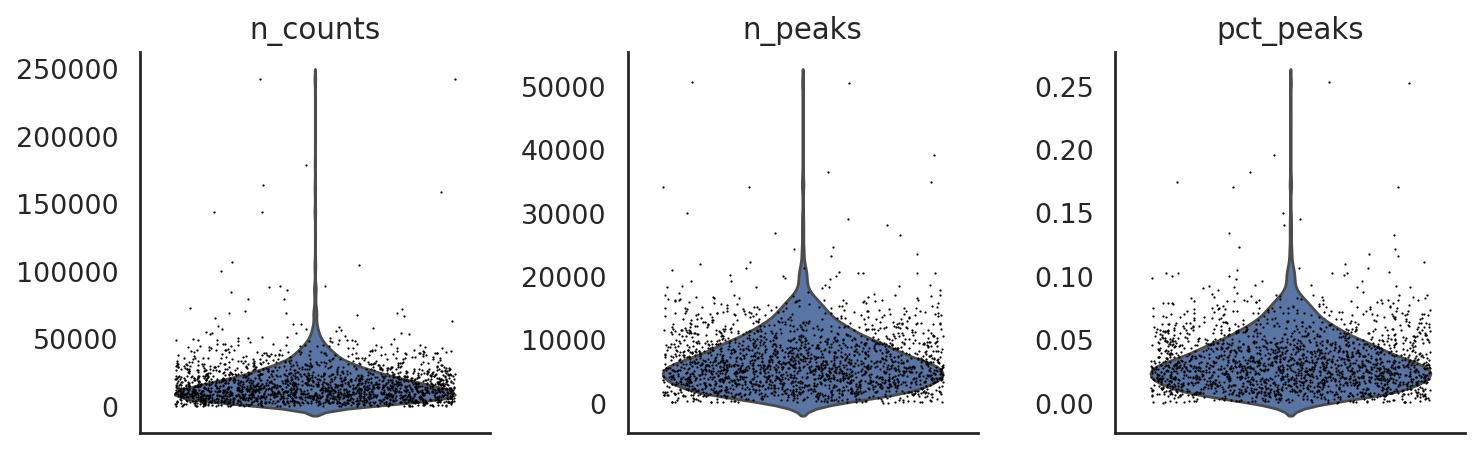

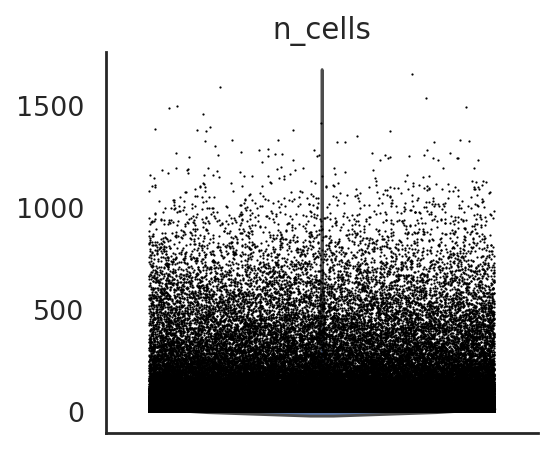

In [18]:
si.pl.violin(adata_CP,
             list_obs=['n_counts', 'n_peaks', 'pct_peaks'],
             list_var=['n_cells'],
             fig_size=(3, 3))

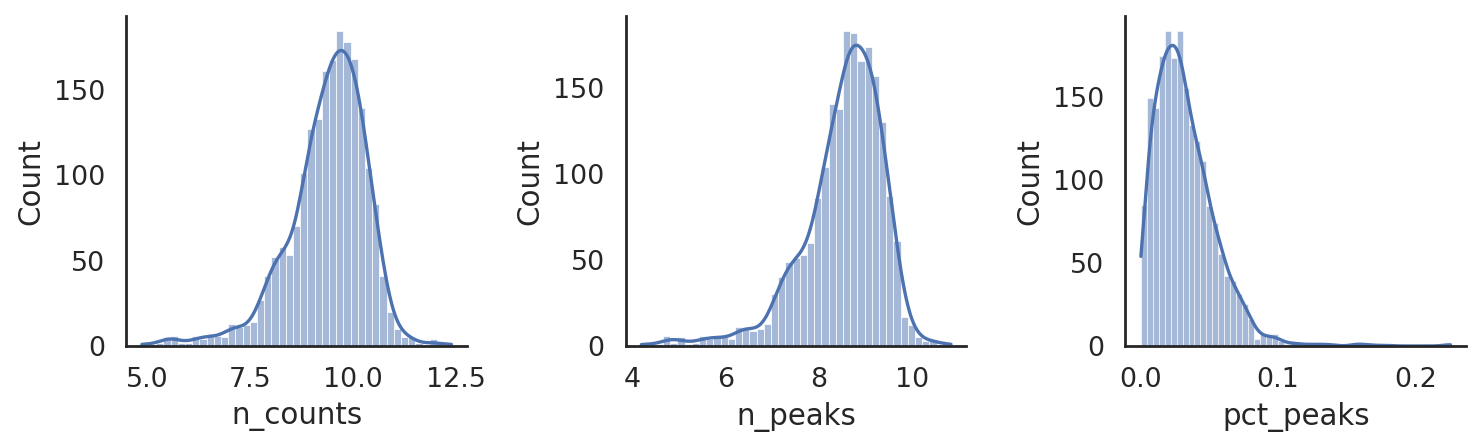

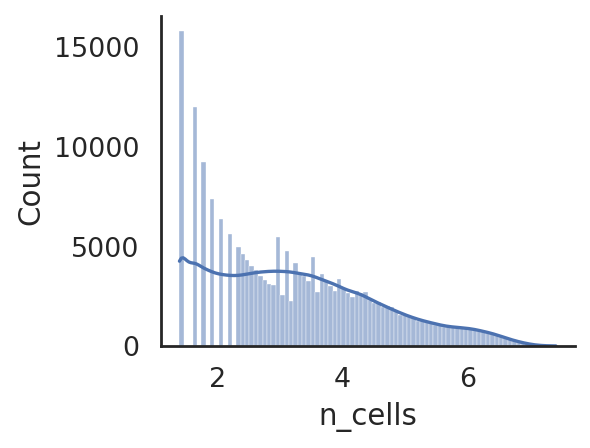

In [19]:
si.pl.hist(adata_CP,
           list_obs=['n_counts', 'n_peaks', 'pct_peaks'],
           log=True,
           list_var=['n_cells'],
           fig_size=(3, 3))

按需过滤低质量 cell（可选）：

In [ ]:
# si.pp.filter_cells_atac(adata_CP, min_n_peaks=100)

Before filtering: 
2034 cells, 200167 peaks
Filter cells based on min_n_peaks
After filtering out low-quality cells: 
2031 cells, 200167 peaks


## Select Peaks (Optional)

只保留与 top PCs 相关的 peaks，可加速后续训练。

In [20]:
si.pp.pca(adata_CP, n_components=50)

the number of selected PC is: 50


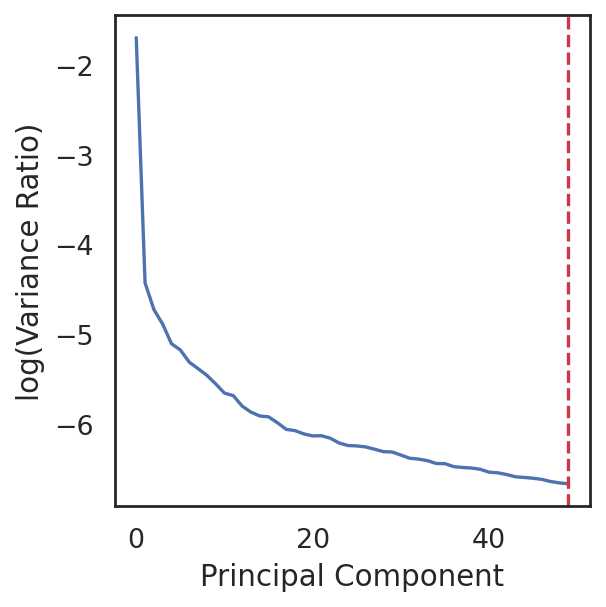

In [21]:
si.pl.pca_variance_ratio(adata_CP, show_cutoff=True)

In [13]:
# # 可选：手动减少保留的 PC 数量（默认用 pca 的全部 50 个）
# si.pp.select_pcs(adata_CP, n_pcs=30)

In [22]:
si.pp.select_pcs_features(adata_CP)

#features selected from PC 0: 33368
#features selected from PC 1: 33415
#features selected from PC 2: 33361
#features selected from PC 3: 33397
#features selected from PC 4: 33375
#features selected from PC 5: 33431
#features selected from PC 6: 33395
#features selected from PC 7: 33442
#features selected from PC 8: 33372
#features selected from PC 9: 33376
#features selected from PC 10: 33364
#features selected from PC 11: 33393
#features selected from PC 12: 33372
#features selected from PC 13: 33434
#features selected from PC 14: 33369
#features selected from PC 15: 33395
#features selected from PC 16: 33422
#features selected from PC 17: 33379
#features selected from PC 18: 33366
#features selected from PC 19: 33498
#features selected from PC 20: 33365
#features selected from PC 21: 33569
#features selected from PC 22: 33364
#features selected from PC 23: 33376
#features selected from PC 24: 33427
#features selected from PC 25: 33367
#features selected from PC 26: 33381
#features s

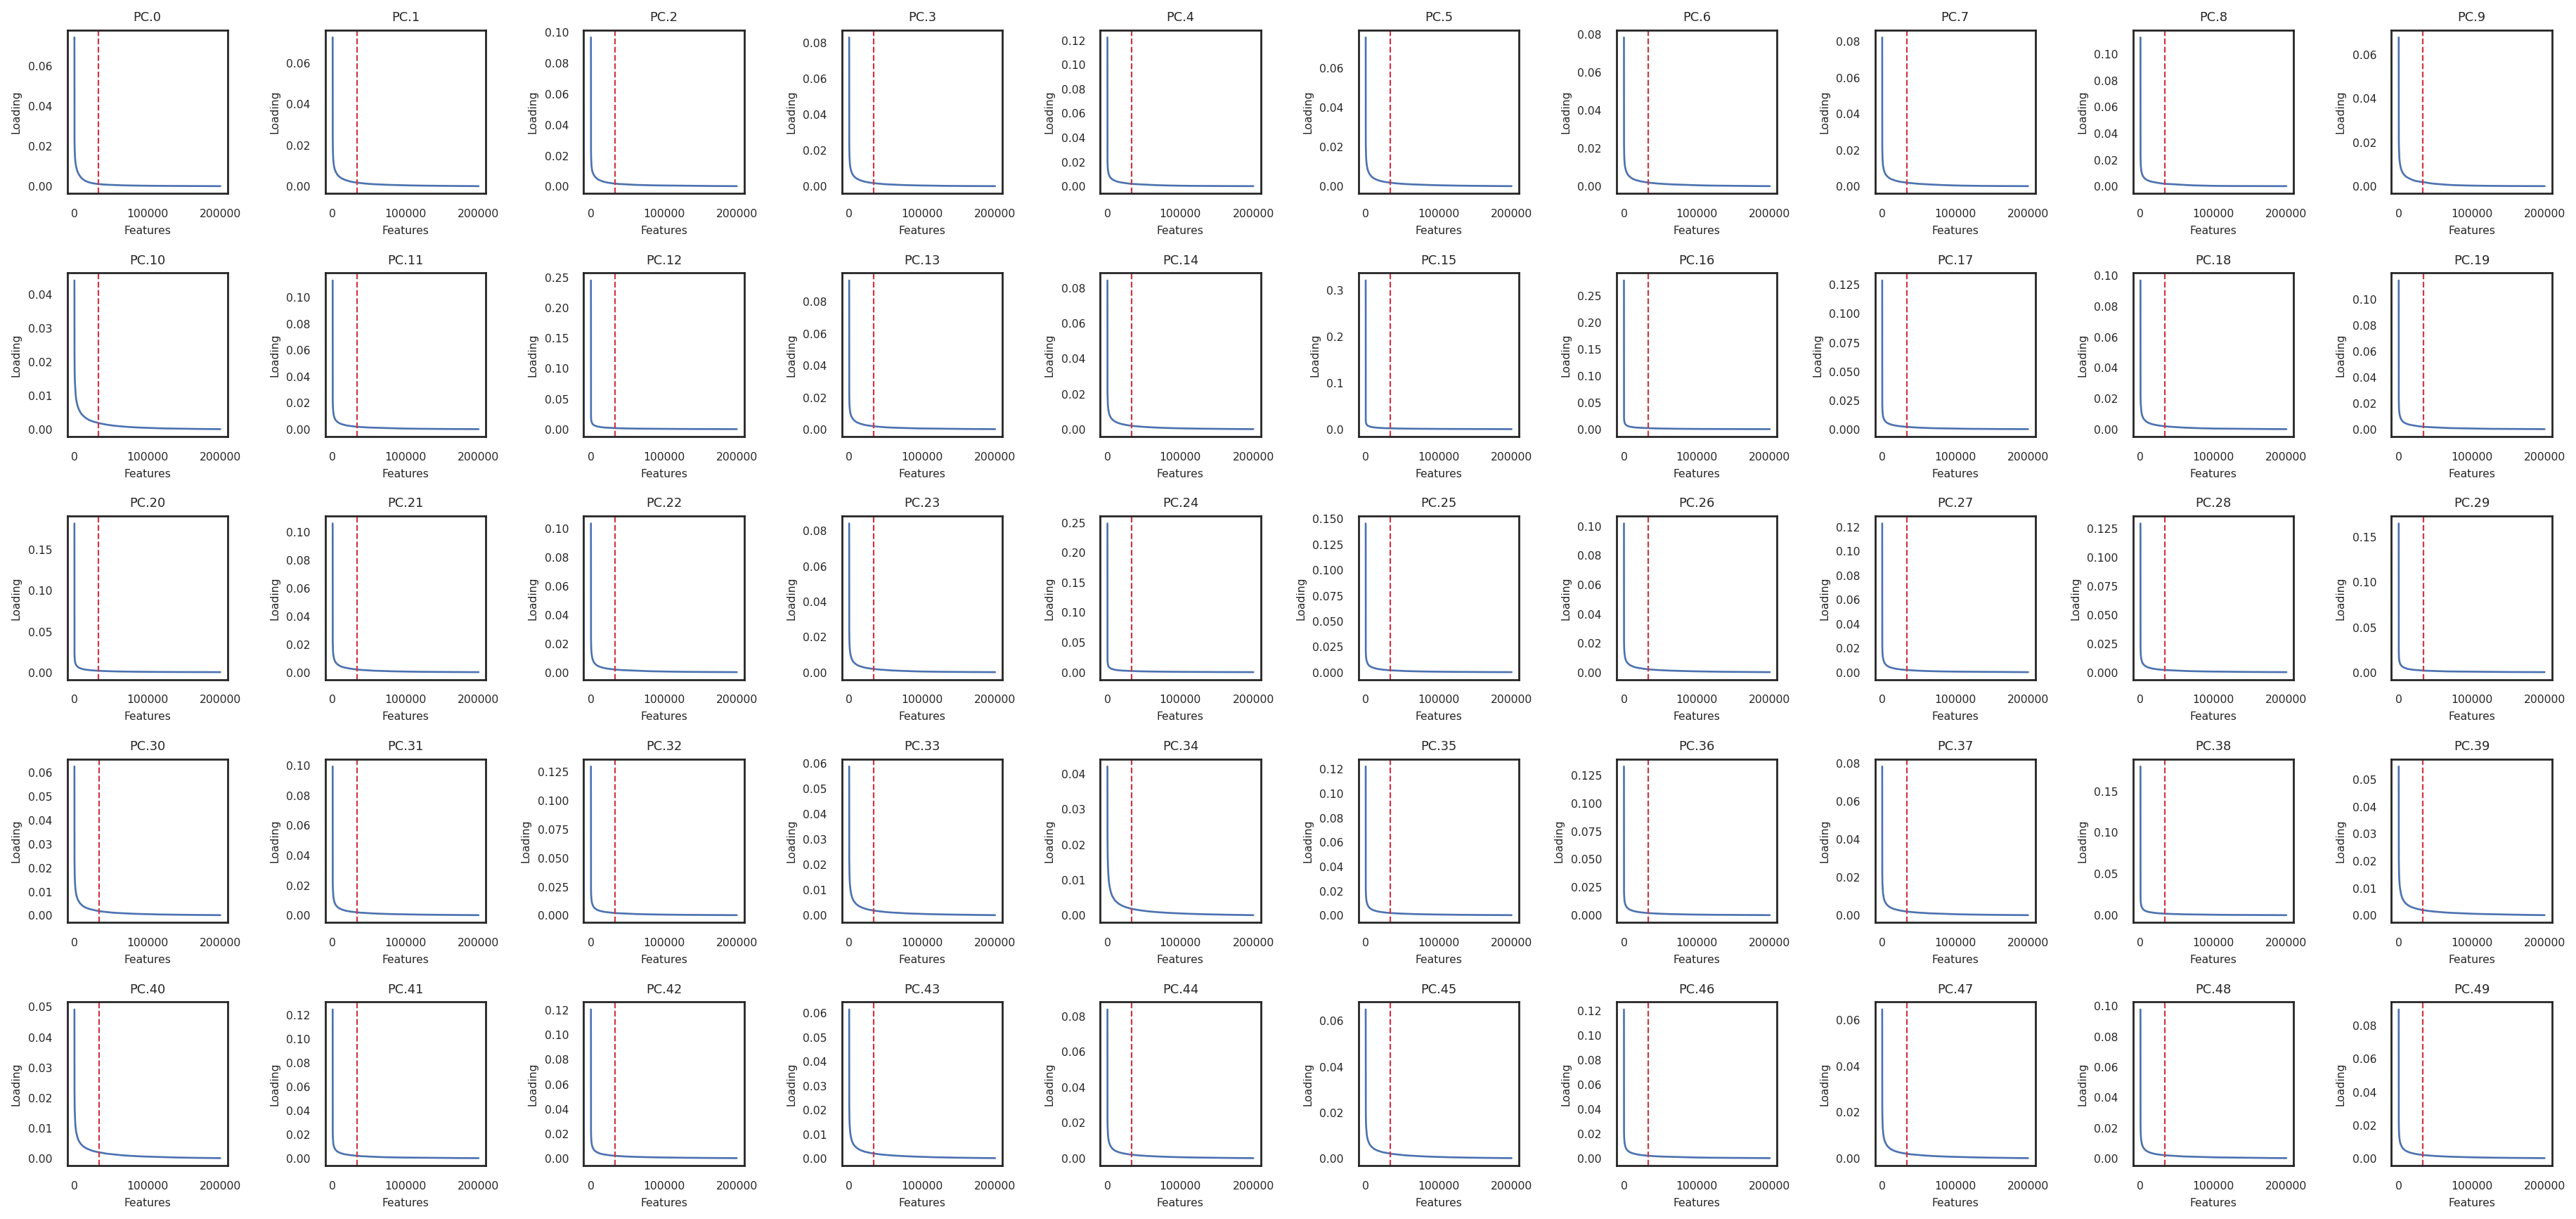

In [23]:
si.pl.pcs_features(adata_CP, fig_ncol=10)

## Select DNA Sequences (Optional)

DNA 序列（TF motifs 或 k-mers）也可编码到图中。

### Step 1: 写出 peaks.bed

In [16]:
si.write_bed(adata_CP, use_top_pcs=True)

"peaks.bed" was written to "result_simba_data_atacseq".


### Step 2: 运行 R 脚本扫描 kmers 和 motifs

**⚠️ 此步骤需要你在本地终端手动执行，完成后再继续运行后续 cell。**

#### 前置准备

1. 安装 R 依赖（如果还没装）：
```bash
conda install r-essentials r-optparse bioconductor-jaspar2020 bioconductor-biostrings bioconductor-tfbstools bioconductor-motifmatchr bioconductor-summarizedexperiment r-doparallel bioconductor-rhdf5 bioconductor-hdf5array
```

2. 下载 hg19 基因组文件（如果还没有）：
```bash
wget https://hgdownload.soe.ucsc.edu/goldenPath/hg19/bigZips/hg19.fa.gz
gunzip hg19.fa.gz
```

3. 进入 workdir 目录运行 R 脚本：
```bash
cd result_simba_atacseq
Rscript ../R_scripts/scan_for_kmers_motifs.R -i peaks.bed -g /path/to/hg19.fa -s 'Homo sapiens'
```

#### 产物

运行成功后，在 `result_simba_atacseq/output_kmers_motifs/` 目录下会生成：
- `freq_kmer.h5`
- `freq_motif.h5`

**确认这两个文件存在后，继续运行下面的 cell。**

In [17]:
# 验证 R 脚本产物是否存在
kmer_path = os.path.join(workdir, 'output_kmers_motifs', 'freq_kmer.h5')
motif_path = os.path.join(workdir, 'output_kmers_motifs', 'freq_motif.h5')

assert os.path.exists(kmer_path), f'Missing: {kmer_path}'
assert os.path.exists(motif_path), f'Missing: {motif_path}'
print('kmer and motif files found!')

kmer and motif files found!


In [18]:
adata_PK = si.read_hdf(kmer_path, 'mat')
adata_PM = si.read_hdf(motif_path, 'mat')

# byte string -> str
adata_PK.obs.index = [x.decode('utf-8') if isinstance(x, bytes) else x for x in adata_PK.obs.index]
adata_PK.var.index = [x.decode('utf-8') if isinstance(x, bytes) else x for x in adata_PK.var.index]
adata_PM.obs.index = [x.decode('utf-8') if isinstance(x, bytes) else x for x in adata_PM.obs.index]
adata_PM.var.index = [x.decode('utf-8') if isinstance(x, bytes) else x for x in adata_PM.var.index]

print('PK:', adata_PK)
print('PM:', adata_PM)

PK: AnnData object with n_obs × n_vars = 134535 × 4096
PM: AnnData object with n_obs × n_vars = 134535 × 633


In [19]:
si.pp.binarize(adata_PK)
si.pp.binarize(adata_PM)

In [20]:
si.pp.pca(adata_PK, n_components=50)
si.pp.pca(adata_PM, n_components=50)

In [21]:
si.pp.select_pcs_features(adata_PK, min_elbow=adata_PK.shape[1] // 5, S=5)
si.pp.select_pcs_features(adata_PM, min_elbow=adata_PM.shape[1] // 5, S=5)

#features selected from PC 0: 819
#features selected from PC 1: 828
#features selected from PC 2: 1491
#features selected from PC 3: 1495
#features selected from PC 4: 1981
#features selected from PC 5: 1710
#features selected from PC 6: 1277
#features selected from PC 7: 1877
#features selected from PC 8: 819
#features selected from PC 9: 1622
#features selected from PC 10: 1464
#features selected from PC 11: 1523
#features selected from PC 12: 1557
#features selected from PC 13: 1671
#features selected from PC 14: 1767
#features selected from PC 15: 1755
#features selected from PC 16: 2032
#features selected from PC 17: 1975
#features selected from PC 18: 819
#features selected from PC 19: 1843
#features selected from PC 20: 2072
#features selected from PC 21: 1766
#features selected from PC 22: 1711
#features selected from PC 23: 1861
#features selected from PC 24: 2002
#features selected from PC 25: 1891
#features selected from PC 26: 1820
#features selected from PC 27: 1886
#featu

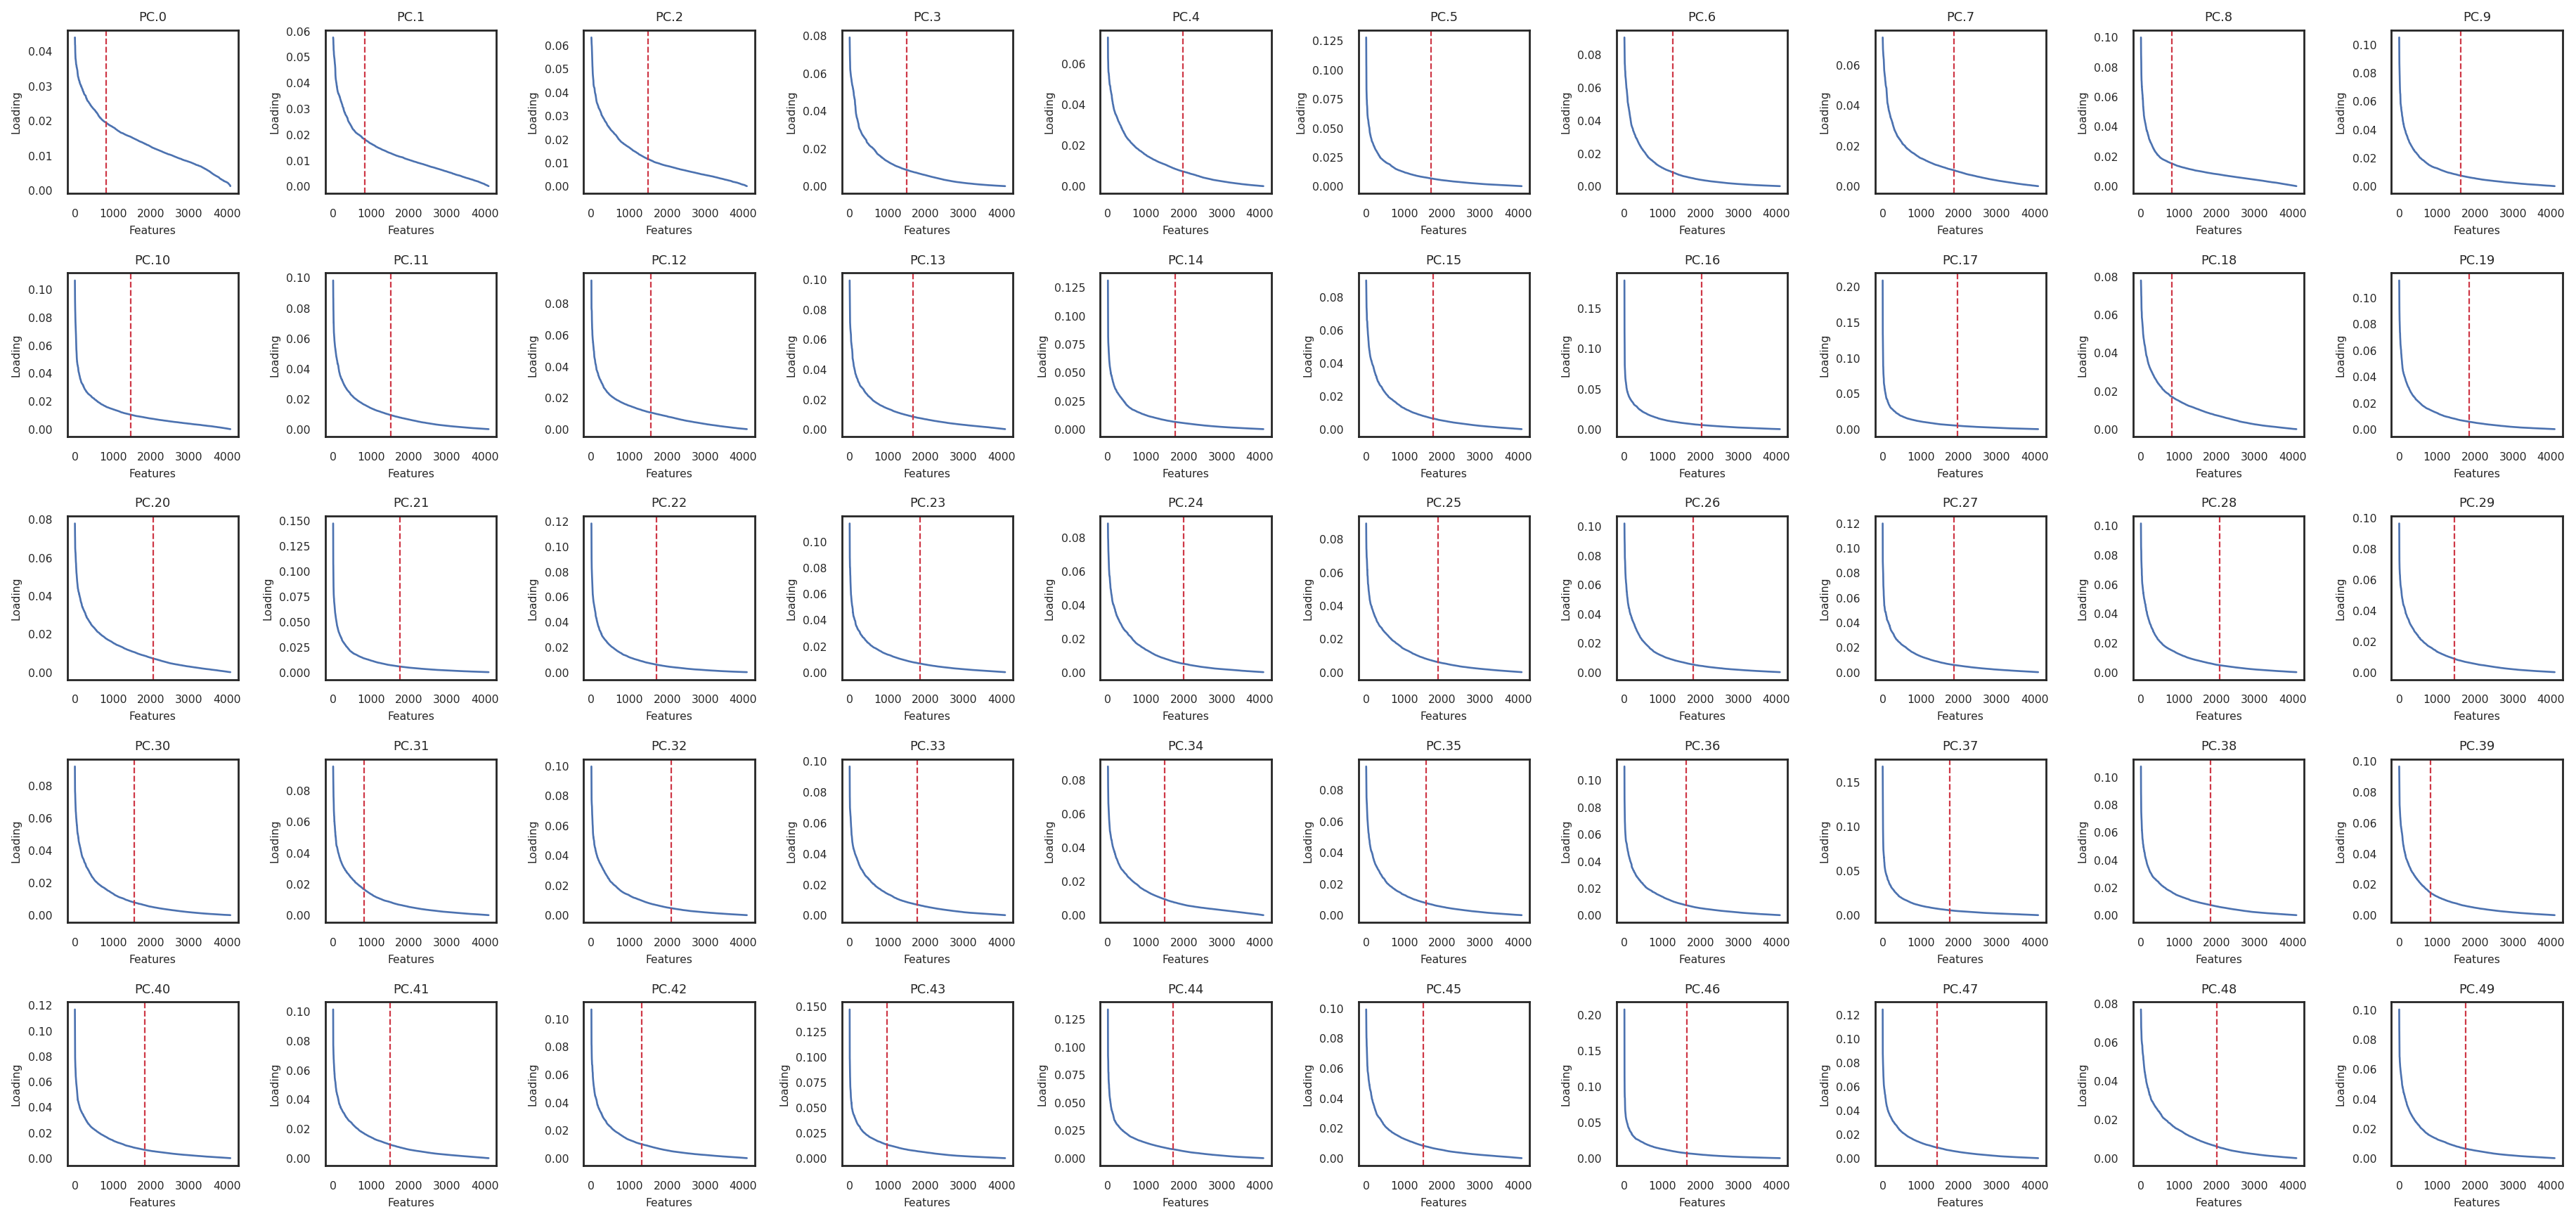

In [22]:
si.pl.pcs_features(adata_PK, fig_ncol=10)

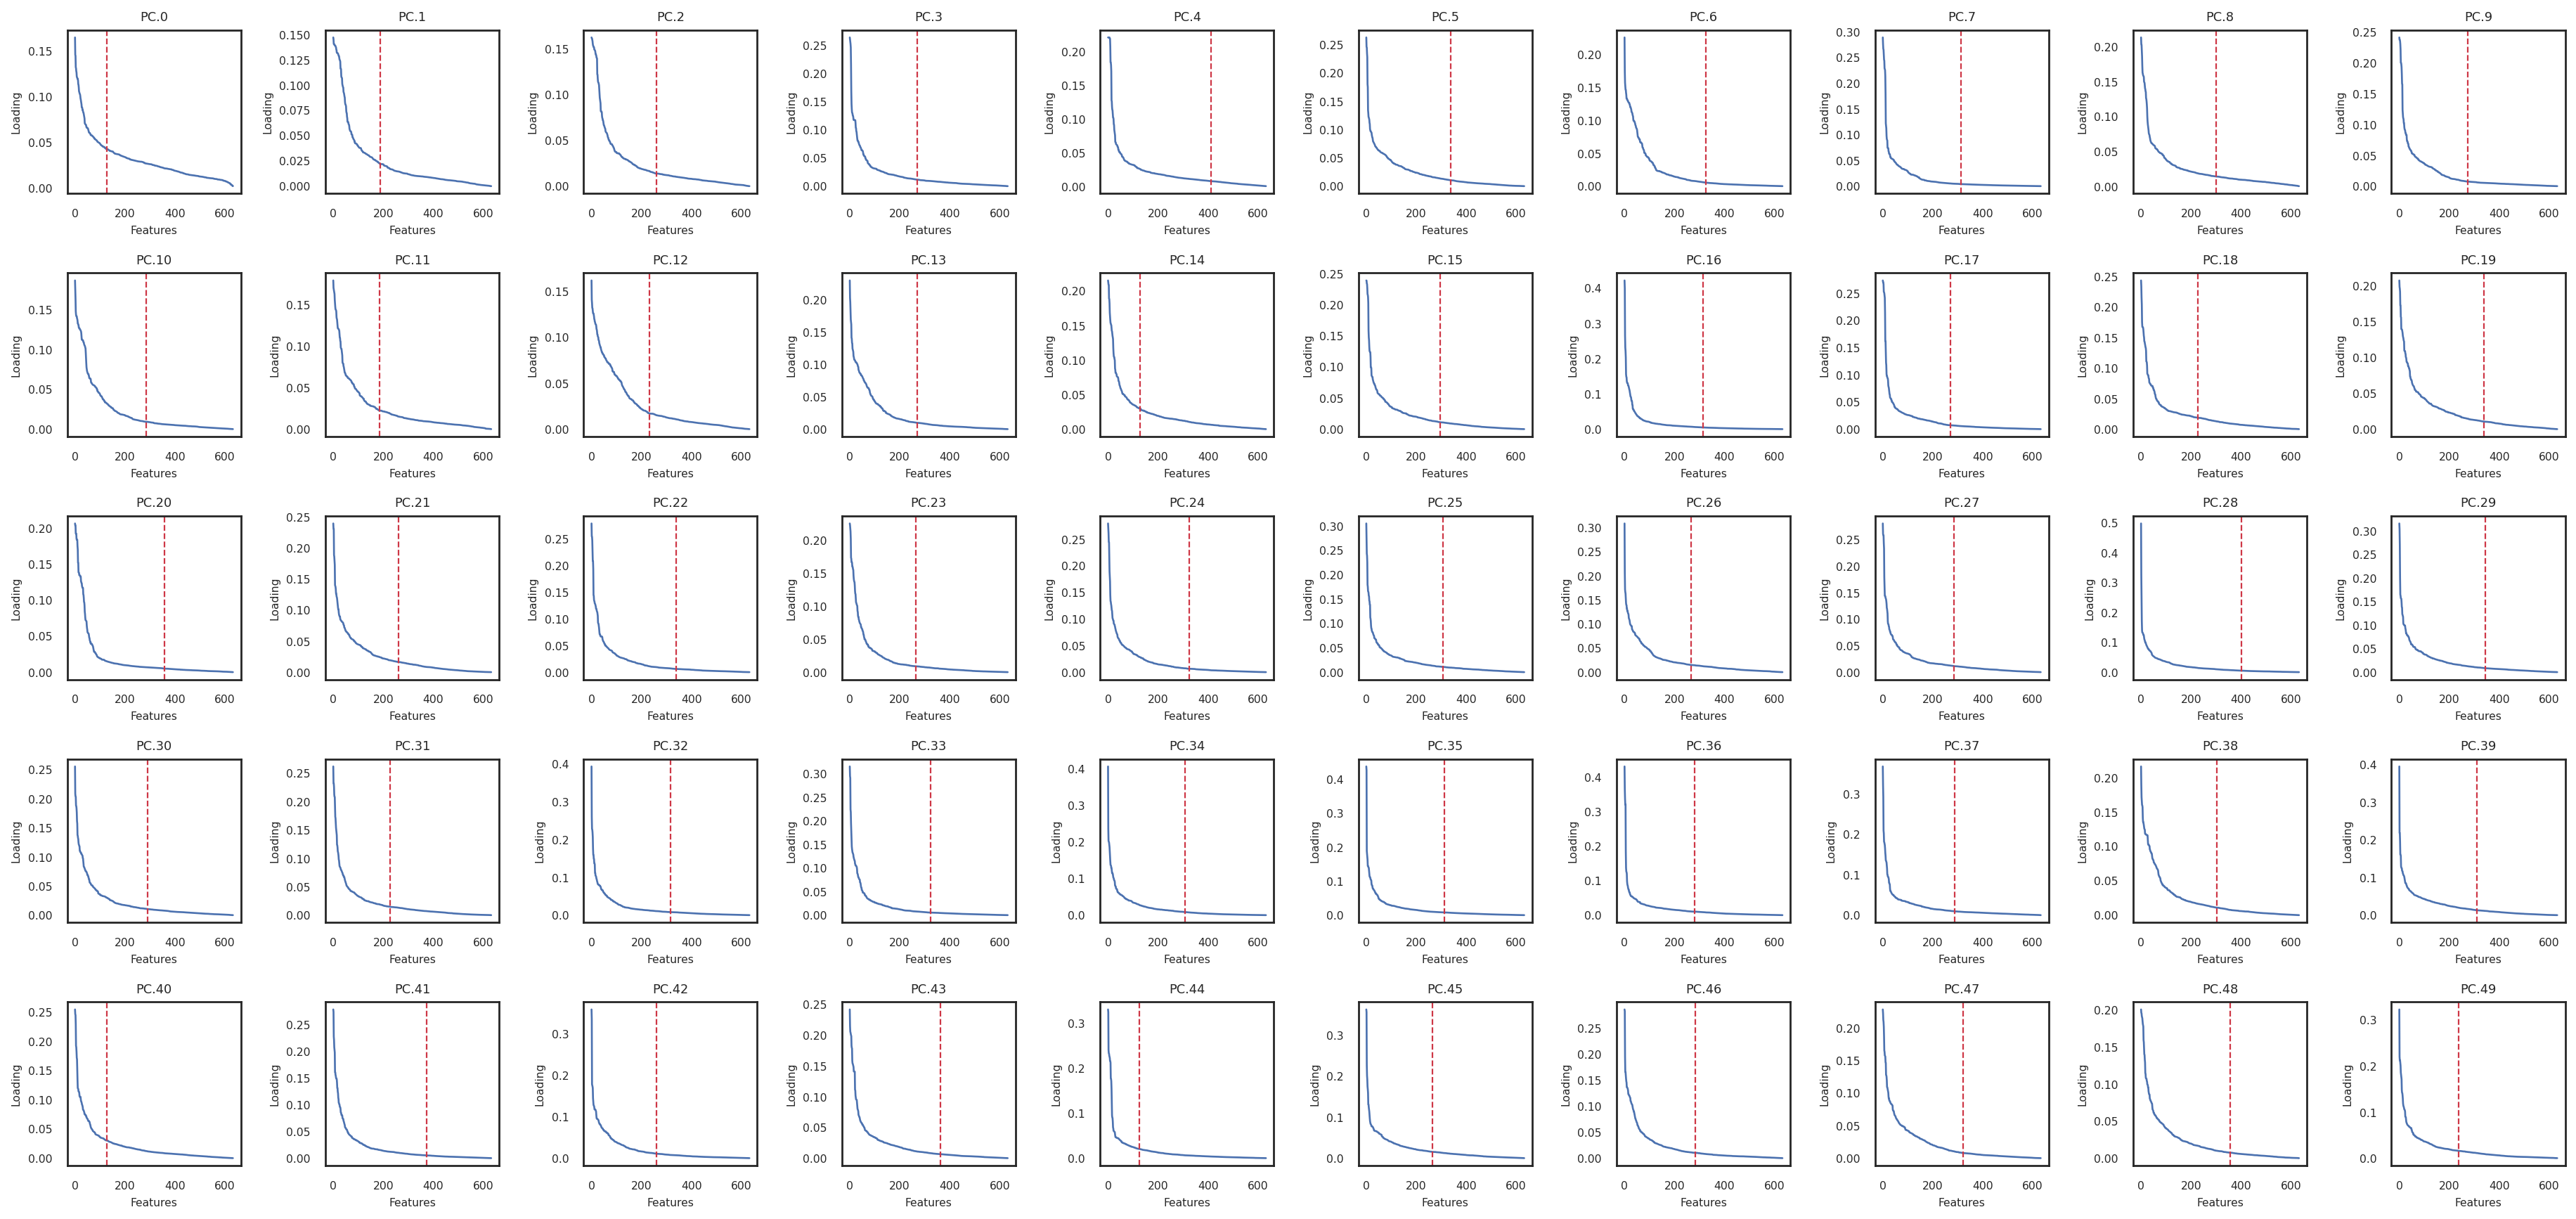

In [23]:
si.pl.pcs_features(adata_PM, fig_ncol=10)

## Generate Graph

In [24]:
si.tl.gen_graph(list_CP=[adata_CP],
                # list_PK=[adata_PK],
                # list_PM=[adata_PM],
                copy=False,
                use_top_pcs=True,
                dirname='graph0')

relation0: source: C, destination: P\n#edges: 12977763
Total number of edges: 12977763
Writing graph file "pbg_graph.txt" to "result_simba_data_only_peaks_atacseq/pbg/graph0" ...
Finished.


## PBG Training

In [25]:
# 查看默认参数
si.settings.pbg_params

{'entity_path': 'result_simba_data_only_peaks_atacseq/pbg/graph0/input/entity',
 'edge_paths': ['result_simba_data_only_peaks_atacseq/pbg/graph0/input/edge'],
 'checkpoint_path': '',
 'entities': {'C': {'num_partitions': 1}, 'P': {'num_partitions': 1}},
 'relations': [{'name': 'r0',
   'lhs': 'C',
   'rhs': 'P',
   'operator': 'none',
   'weight': 1.0}],
 'dynamic_relations': False,
 'dimension': 50,
 'global_emb': False,
 'comparator': 'dot',
 'num_epochs': 10,
 'workers': 4,
 'num_batch_negs': 50,
 'num_uniform_negs': 50,
 'loss_fn': 'softmax',
 'lr': 0.1,
 'early_stopping': False,
 'regularization_coef': 0.0,
 'wd': 0.0,
 'wd_interval': 50,
 'eval_fraction': 0.05,
 'eval_num_batch_negs': 50,
 'eval_num_uniform_negs': 50,
 'checkpoint_preservation_interval': None}

In [26]:
dict_config = si.settings.pbg_params.copy()
dict_config['workers'] = 24

si.tl.pbg_train(pbg_params=dict_config,
                auto_wd=True,
                save_wd=True,
                output='model')

Auto-estimated weight decay is 0.00273
`.settings.pbg_params['wd']` has been updated to 0.00273
Converting input data ...
[2026-03-03 21:10:17.775721] Using the 1 relation types given in the config
[2026-03-03 21:10:17.776402] Searching for the entities in the edge files...
[2026-03-03 21:10:32.890054] Entity type C:
[2026-03-03 21:10:32.890752] - Found 2034 entities
[2026-03-03 21:10:32.891248] - Removing the ones with fewer than 1 occurrences...
[2026-03-03 21:10:32.891961] - Left with 2034 entities
[2026-03-03 21:10:32.892305] - Shuffling them...
[2026-03-03 21:10:32.893699] Entity type P:
[2026-03-03 21:10:32.894030] - Found 134535 entities
[2026-03-03 21:10:32.894444] - Removing the ones with fewer than 1 occurrences...
[2026-03-03 21:10:32.911956] - Left with 134535 entities
[2026-03-03 21:10:32.912482] - Shuffling them...
[2026-03-03 21:10:32.989517] Preparing counts and dictionaries for entities and relation types:
[2026-03-03 21:10:32.990572] - Writing count of entity type C a

/root/miniconda3/envs/env_simba/lib/python3.12/site-packages/torchbiggraph/tensorlist.py:86: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  if data.numel() == 0 and data.storage().size() == 0:


[2026-03-03 21:11:20.452039] - Processed 12977763 edges in total
Starting training ...


/root/miniconda3/envs/env_simba/lib/python3.12/site-packages/torchbiggraph/tensorlist.py:86: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  if data.numel() == 0 and data.storage().size() == 0:
/root/miniconda3/envs/env_simba/lib/python3.12/site-packages/torchbiggraph/tensorlist.py:86: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  if data.numel() == 0 and data.storage().size() == 0:
/root/miniconda3/envs/env_simba/lib/python3.12/site-packages/torchbiggraph/tensorlist.py:86: UserWarning: TypedStorage is deprecated. 

Finished


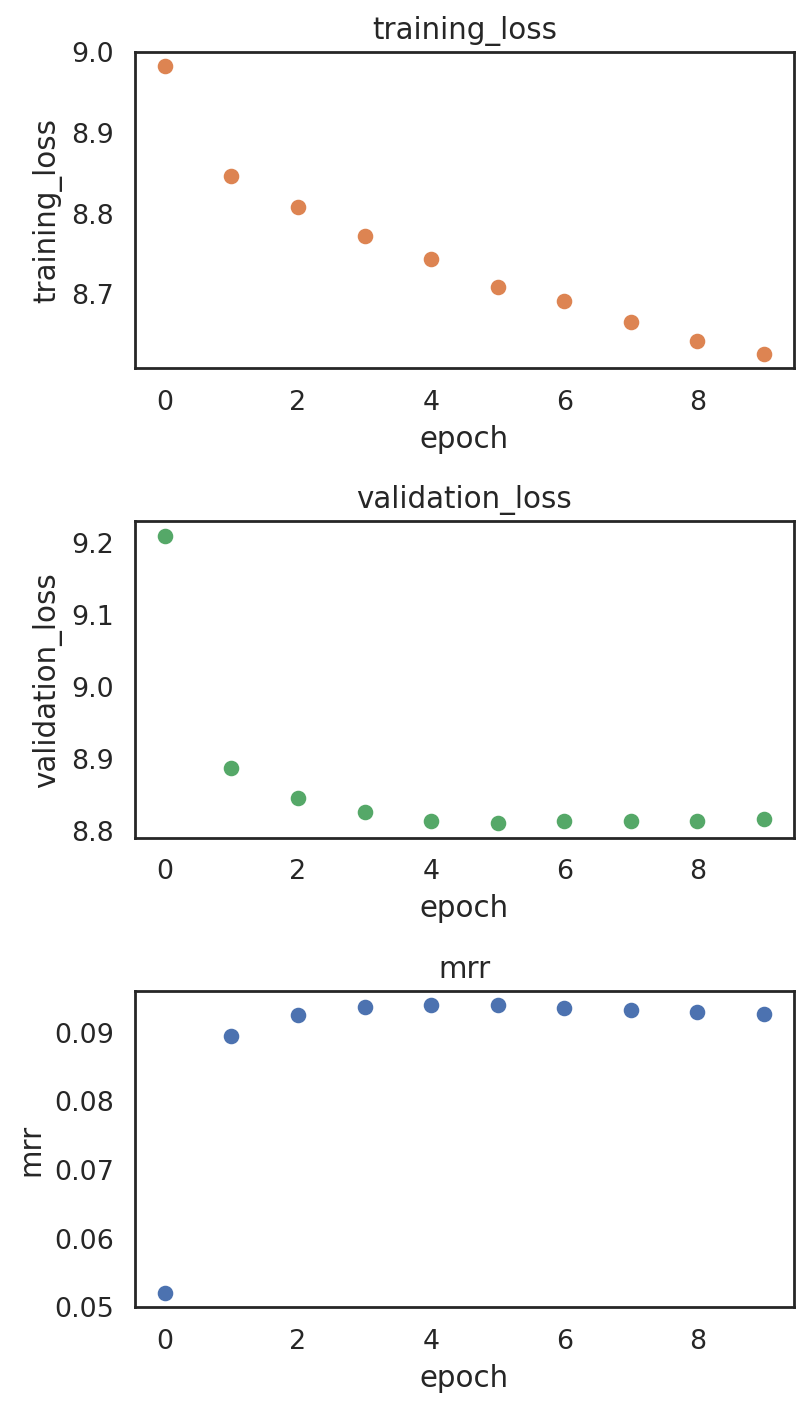

In [27]:
si.pl.pbg_metrics(fig_ncol=1)

## Post-training Analysis

In [28]:
palette_celltype = {
    'HSC': '#00441B', 'MPP': '#46A040', 'LMPP': '#00AF99',
    'CMP': '#FFC179', 'CLP': '#98D9E9', 'MEP': '#F6313E',
    'GMP': '#FFA300', 'pDC': '#C390D4', 'mono': '#FF5A00',
    'UNK': '#333333',
}

In [29]:
dict_adata = si.read_embedding()
dict_adata

{'C': AnnData object with n_obs × n_vars = 2034 × 50,
 'P': AnnData object with n_obs × n_vars = 134535 × 50}

In [31]:
adata_C = dict_adata['C']  # cells
adata_P = dict_adata['P']  # peaks
# adata_M = dict_adata['M']  # motifs
# adata_K = dict_adata['K']  # kmers

print('C:', adata_C)
print('P:', adata_P)
# print('M:', adata_M)
# print('K:', adata_K)

C: AnnData object with n_obs × n_vars = 2034 × 50
P: AnnData object with n_obs × n_vars = 134535 × 50


### Visualize Cell Embeddings

In [32]:
adata_C.obs['celltype'] = adata_CP[adata_C.obs_names, :].obs['celltype'].copy()
adata_C

AnnData object with n_obs × n_vars = 2034 × 50
    obs: 'celltype'

In [33]:
si.tl.umap(adata_C, n_neighbors=15, n_components=2)

/root/miniconda3/envs/env_simba/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


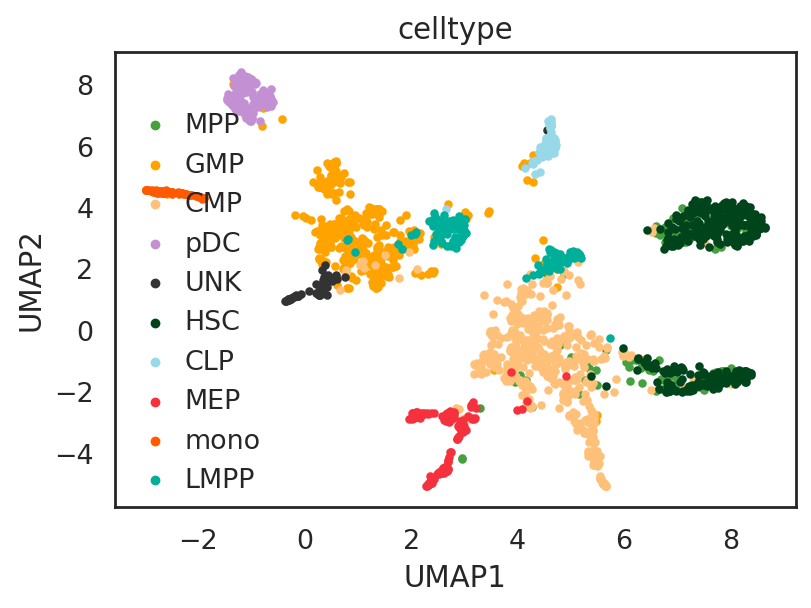

In [34]:
si.pl.umap(adata_C,
           color=['celltype'],
           dict_palette={'celltype': palette_celltype},
           fig_size=(4.5, 4),
           drawing_order='random')

### Visualize All Entity Embeddings (Cells + Motifs + Kmers + Peaks)

In [34]:
adata_all = si.tl.embed(adata_ref=adata_C,
                        list_adata_query=[adata_M, adata_K, adata_P])

Performing softmax transformation for query data 0;
Performing softmax transformation for query data 1;
Performing softmax transformation for query data 2;


In [35]:
adata_all.obs['entity_anno'] = ''
adata_all.obs.loc[adata_C.obs_names, 'entity_anno'] = adata_all.obs.loc[adata_C.obs_names, 'celltype'].tolist()
adata_all.obs.loc[adata_P.obs_names, 'entity_anno'] = 'peak'
adata_all.obs.loc[adata_K.obs_names, 'entity_anno'] = 'kmer'
adata_all.obs.loc[adata_M.obs_names, 'entity_anno'] = 'motif'

adata_all.obs.head()

,celltype,id_dataset,entity_anno
singles-BM0828-MPP-frozen-151103-31,MPP,ref,MPP
singles-20160617-scATAC-BM1214-CMP-LS-65,CMP,ref,CMP
singles-BM0106-HSC-LS-160219-23,HSC,ref,HSC
singles-BM0828-MPP-frozen-151103-55,MPP,ref,MPP
BM1077-MPP-Frozen-160105-31,MPP,ref,MPP


In [36]:
si.tl.umap(adata_all, n_neighbors=15, n_components=2)

/root/miniconda3/envs/env_simba/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [37]:
palette_entity_anno = palette_celltype.copy()
palette_entity_anno['peak'] = '#e5c2c8'
palette_entity_anno['kmer'] = '#94b1b7'
palette_entity_anno['motif'] = '#92ba79'

/root/autodl-tmp/simba_for_atac/simba/plotting/_plot.py:379: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["color"] = {}


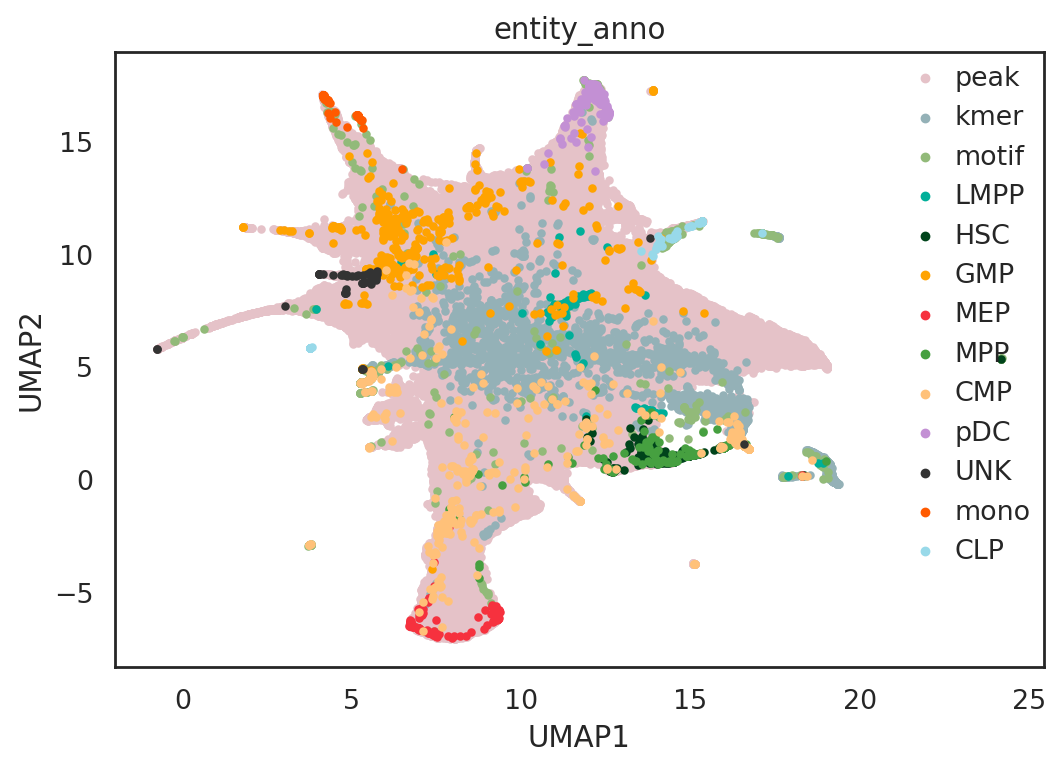

In [38]:
si.pl.umap(adata_all[::-1, ],
           color=['entity_anno'],
           dict_palette={'entity_anno': palette_entity_anno},
           fig_size=(6, 5),
           drawing_order='original',
           show_texts=False)

In [39]:
marker_tfs = ['PAX5', 'EBF1',
              'TCF12(var.2)', 'IRF8', 'TCF4',
              'CEBPB', 'CEBPD',
              'MEIS1(var.2)', 'HOXA9', 'HOXA4',
              'GATA1', 'GATA3',
              'ATF4', 'STAT1',
              'ETV6']

marker_kmers = ['GATAAG', 'CAGCTG', 'ATAAAT', 'AGGAAA', 'CACTTC']

marker_peaks = []

/root/autodl-tmp/simba_for_atac/simba/plotting/_plot.py:379: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["color"] = {}
Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


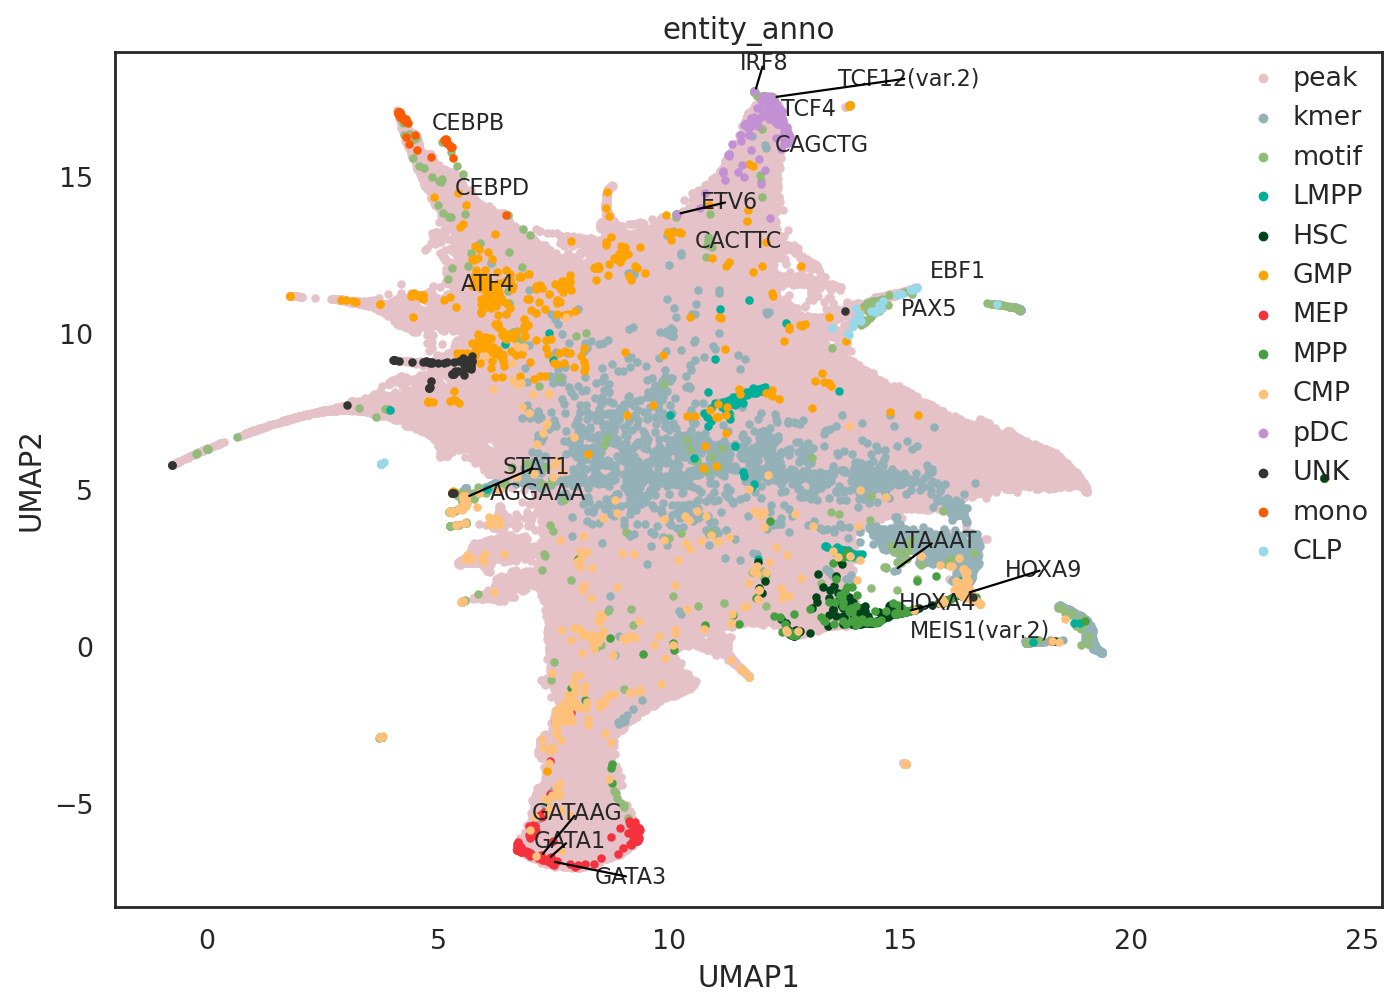

In [40]:
si.pl.umap(adata_all[::-1, ],
           color=['entity_anno'],
           dict_palette={'entity_anno': palette_entity_anno},
           drawing_order='original',
           texts=marker_tfs + marker_kmers + marker_peaks,
           text_expand=(1.5, 2),
           show_texts=True,
           fig_size=(8, 6.5))

### SIMBA Metrics

In [41]:
# motifs
adata_cmp_CM = si.tl.compare_entities(adata_ref=adata_C,
                                      adata_query=adata_M)

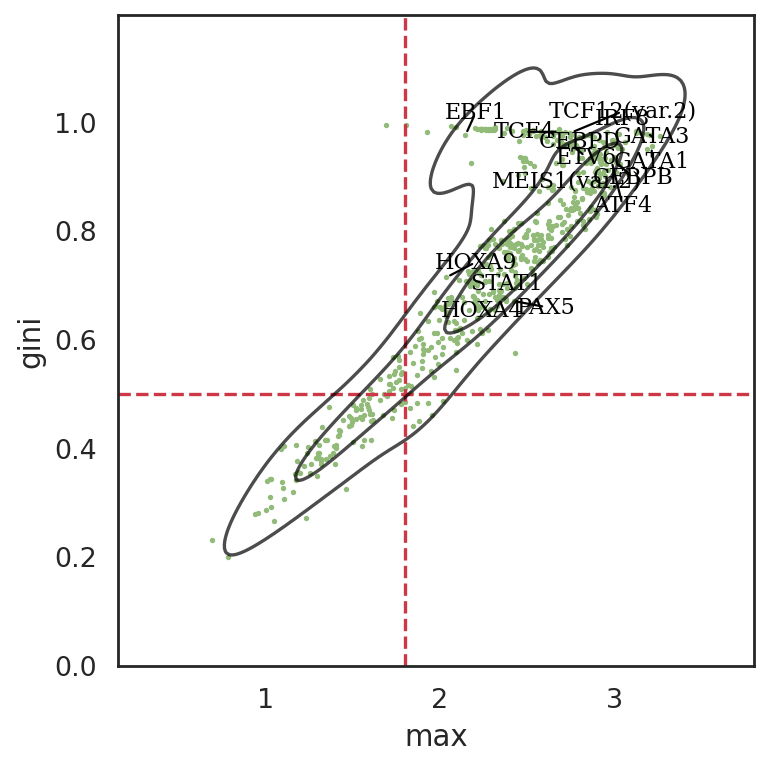

In [42]:
si.pl.entity_metrics(adata_cmp_CM,
                     x='max', y='gini',
                     show_texts=True,
                     show_cutoff=True,
                     show_contour=True,
                     texts=marker_tfs,
                     text_expand=(1.5, 1.5),
                     size=2,
                     cutoff_x=1.8,
                     cutoff_y=0.5,
                     c='#92ba79',
                     save_fig=False)

In [43]:
# kmers
adata_cmp_CK = si.tl.compare_entities(adata_ref=adata_C,
                                      adata_query=adata_K)

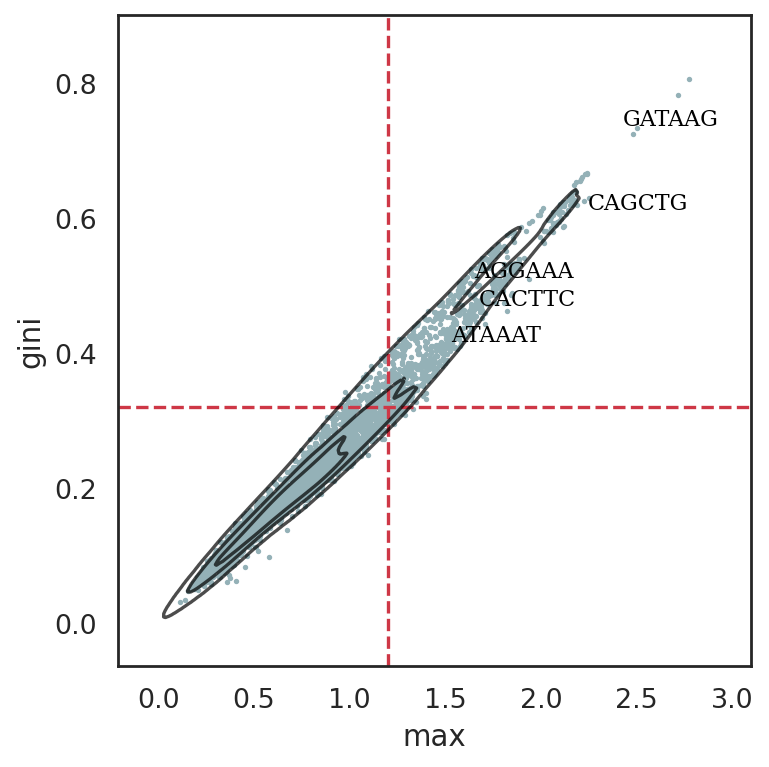

In [44]:
si.pl.entity_metrics(adata_cmp_CK,
                     x='max', y='gini',
                     show_texts=True,
                     show_cutoff=True,
                     show_contour=True,
                     texts=marker_kmers,
                     text_expand=(1.5, 1.5),
                     size=2,
                     cutoff_x=1.2,
                     cutoff_y=0.32,
                     c='#94b1b7',
                     save_fig=False)

### SIMBA Barcode Plots

In [45]:
adata_cmp_CM.obs['celltype'] = adata_CP.obs.loc[adata_cmp_CM.obs_names, 'celltype']
adata_cmp_CK.obs['celltype'] = adata_CP.obs.loc[adata_cmp_CK.obs_names, 'celltype']

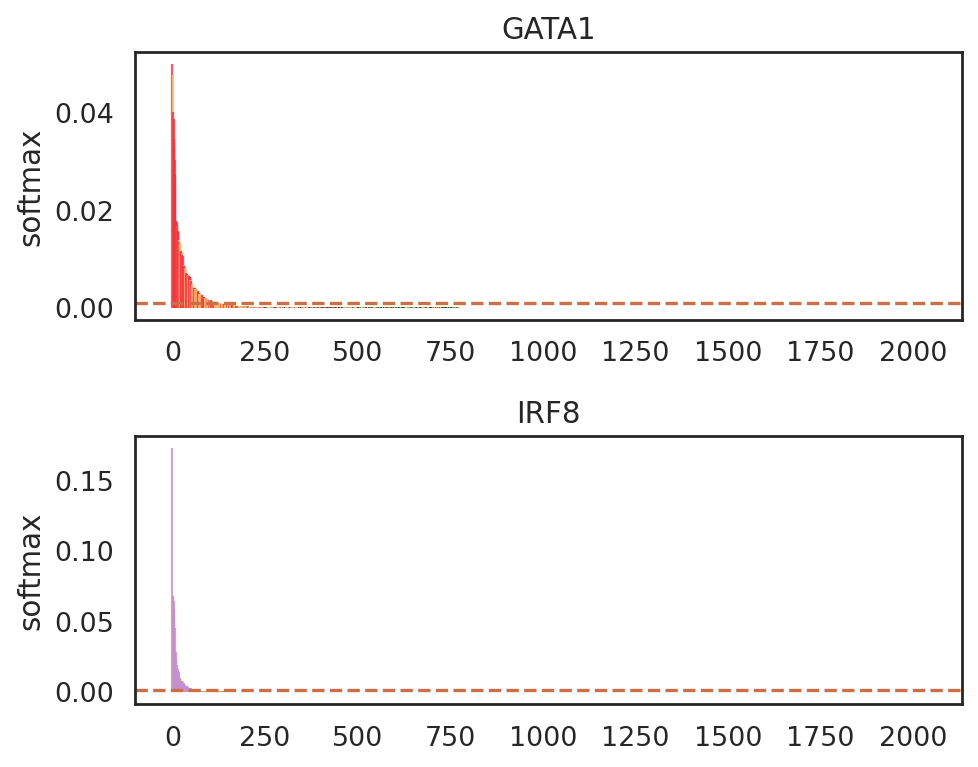

In [46]:
si.pl.entity_barcode(adata_cmp_CM,
                     layer='softmax',
                     entities=['GATA1', 'IRF8'],
                     anno_ref='celltype',
                     show_cutoff=True,
                     cutoff=0.001,
                     palette=palette_celltype,
                     fig_size=(6, 2.5),
                     save_fig=False)

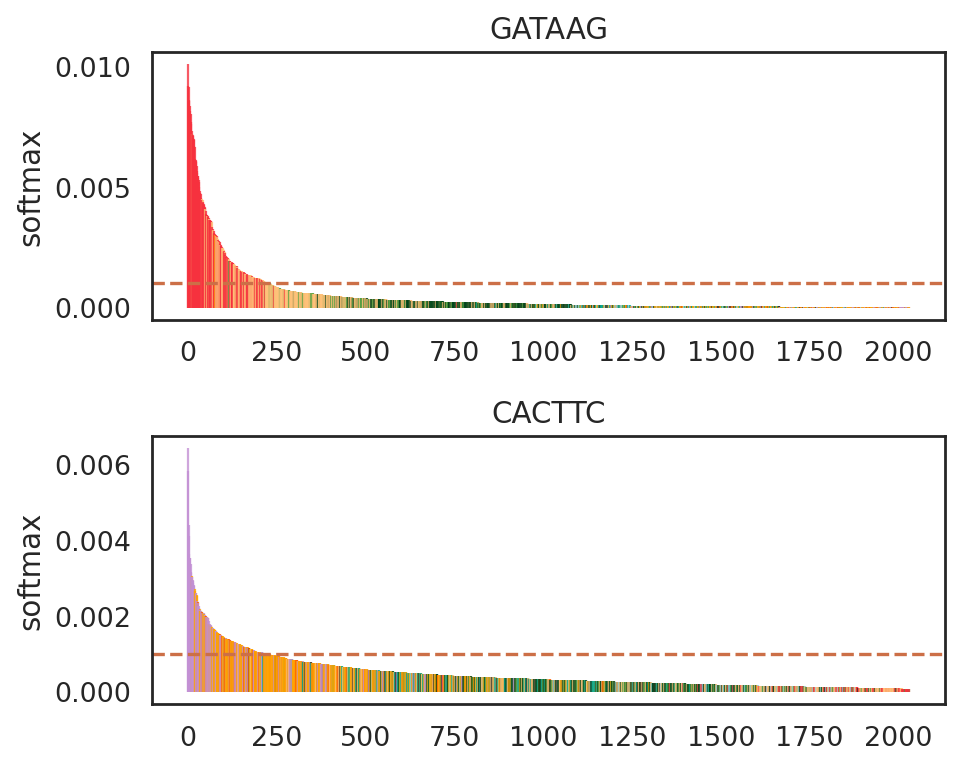

In [47]:
si.pl.entity_barcode(adata_cmp_CK,
                     layer='softmax',
                     entities=['GATAAG', 'CACTTC'],
                     anno_ref='celltype',
                     show_cutoff=True,
                     cutoff=0.001,
                     palette=palette_celltype,
                     fig_size=(6, 2.5),
                     save_fig=False)

### SIMBA Queries

/root/autodl-tmp/simba_for_atac/simba/plotting/_plot.py:379: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["color"] = {}


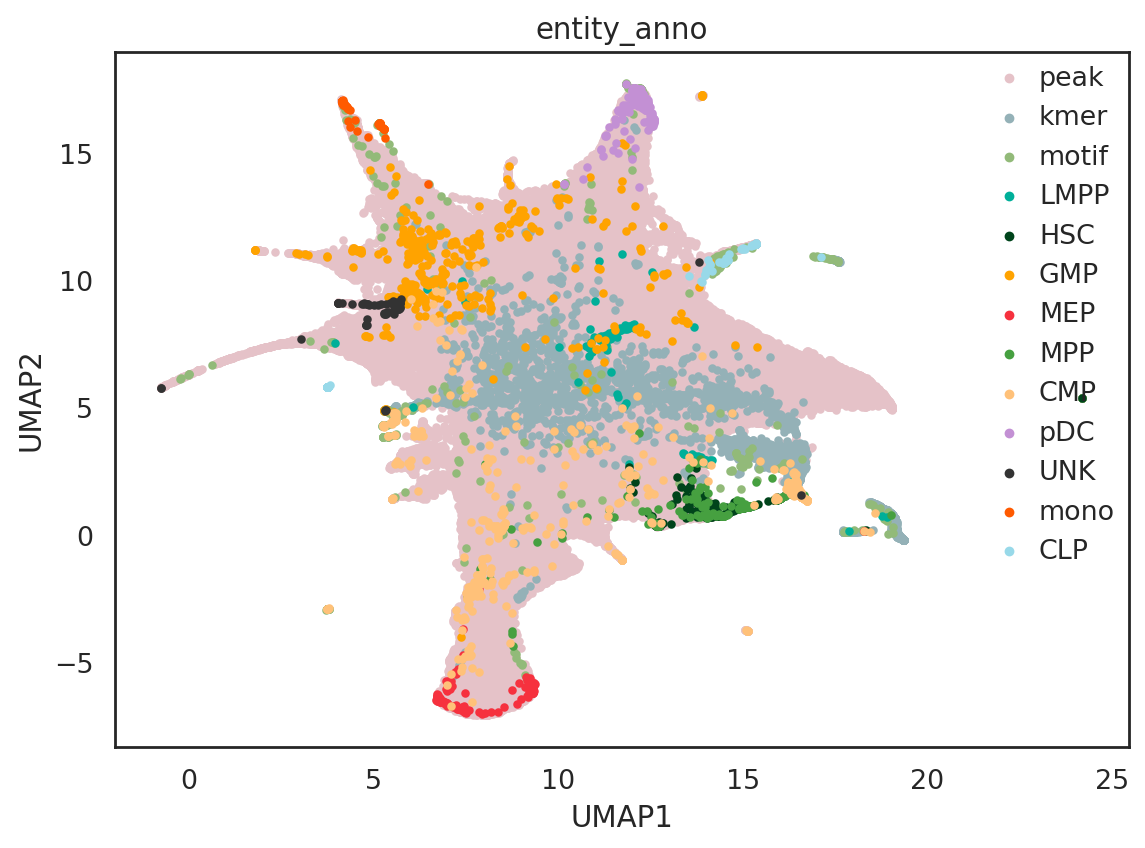

In [48]:
si.pl.umap(adata_all[::-1, ],
           color=['entity_anno'],
           dict_palette={'entity_anno': palette_entity_anno},
           drawing_order='original',
           fig_size=(6.5, 5.5))

In [49]:
# 在 UMAP 上以坐标 [-1.5, 16] 为圆心查找附近的 motif/kmer
query_result = si.tl.query(adata_all,
                           pin=[-1.5, 16],
                           obsm='X_umap',
                           use_radius=True, r=2,
                           anno_filter='entity_anno',
                           filters=['motif', 'kmer'])
print(query_result.shape)
query_result.iloc[:10, ]

(0, 5)


,celltype,id_dataset,entity_anno,distance,query


/root/autodl-tmp/simba_for_atac/simba/plotting/_post_training.py:611: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if(ann in adata.obs_keys()):
/root/autodl-tmp/simba_for_atac/simba/plotting/_post_training.py:614: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
  if 'color' not in adata.uns_keys():


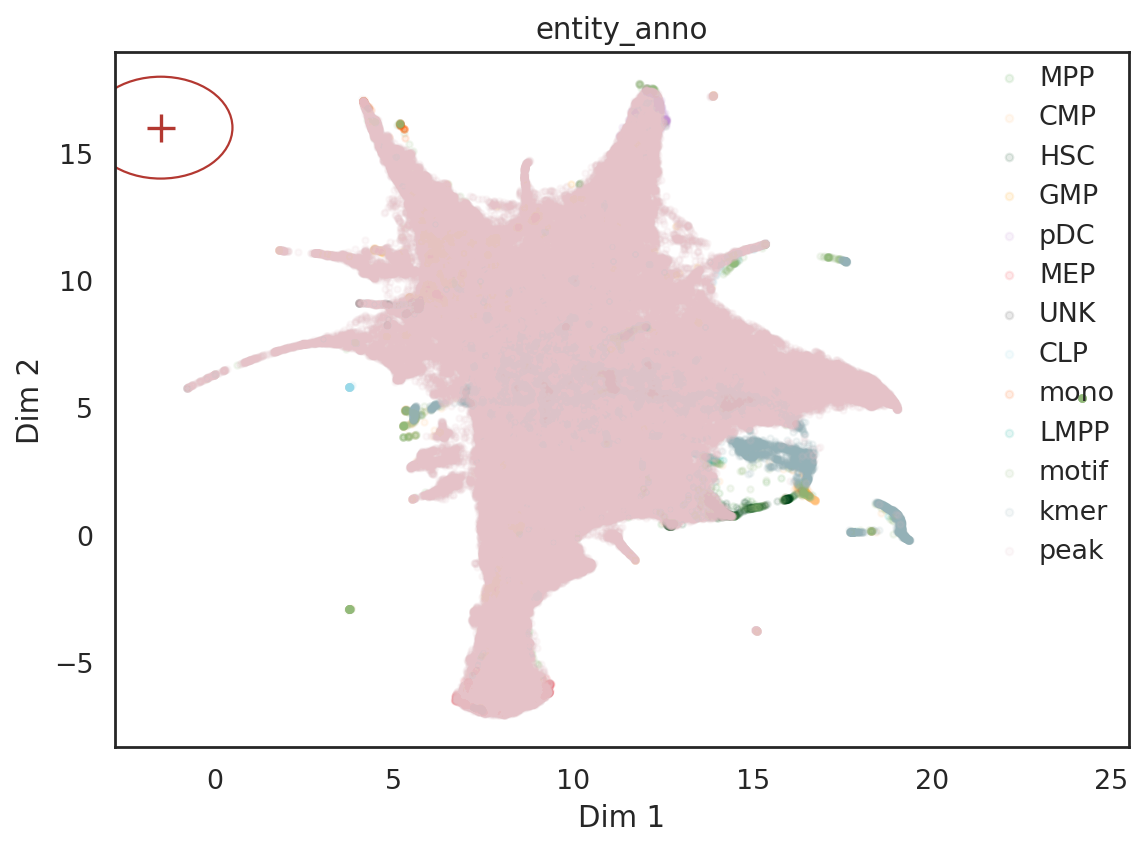

In [50]:
si.pl.query(adata_all,
            show_texts=False,
            color=['entity_anno'],
            dict_palette={'entity_anno': palette_entity_anno},
            alpha=0.9,
            alpha_bg=0.1,
            fig_size=(6.5, 5.5))

In [51]:
# 在 SIMBA embedding 空间中找 CEBPB motif 附近的 top 500 peaks
query_result = si.tl.query(adata_all,
                           entity=['CEBPB'],
                           obsm=None,
                           use_radius=False,
                           k=500,
                           anno_filter='entity_anno',
                           filters=['peak'])
print(query_result.shape)
query_result.head()

(500, 5)


,celltype,id_dataset,entity_anno,distance,query
chr11_61456245_61456704,NaN,query_2,peak,0.827943,CEBPB
chr2_174888719_174889376,NaN,query_2,peak,0.844656,CEBPB
chr10_104575728_104576298,NaN,query_2,peak,0.853254,CEBPB
chr1_145114176_145114911,NaN,query_2,peak,0.871041,CEBPB
chr12_100970493_100970844,NaN,query_2,peak,0.871911,CEBPB


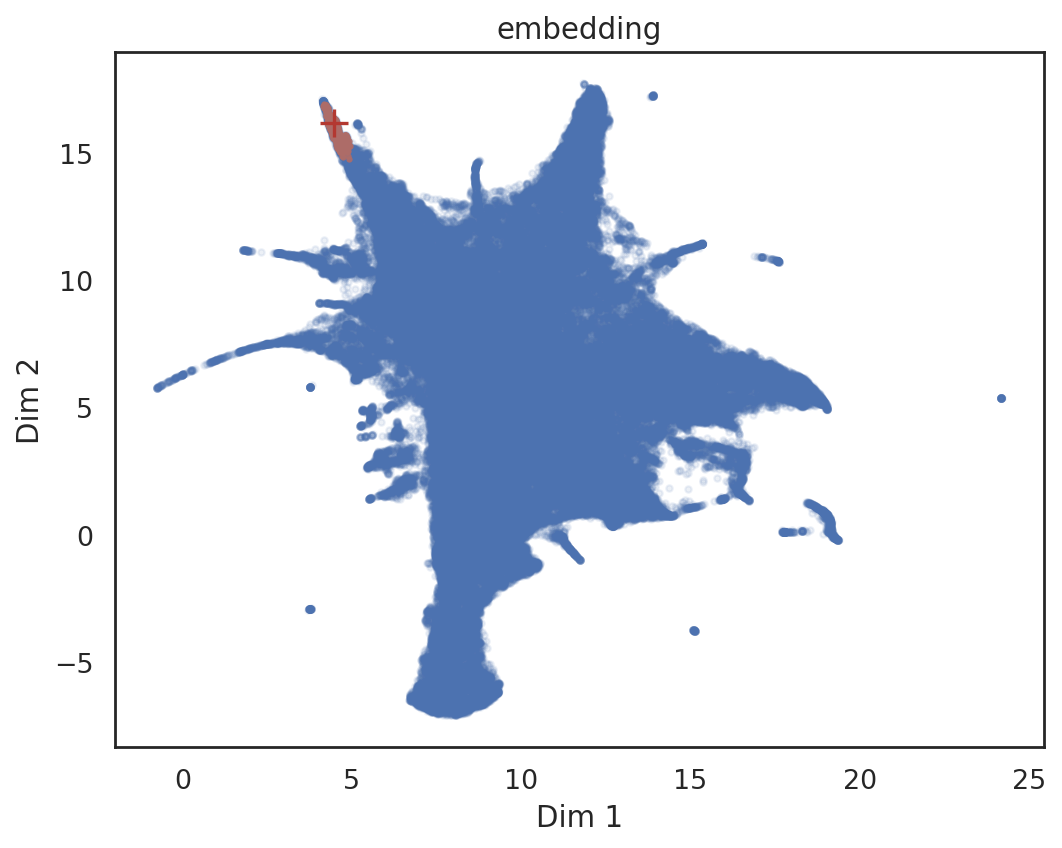

In [52]:
si.pl.query(adata_all,
            show_texts=False,
            alpha=0.9,
            alpha_bg=0.1,
            fig_size=(6., 5.5))

In [53]:
# 在 UMAP 空间中找 PAX5 motif 附近的所有实体
query_result = si.tl.query(adata_all,
                           entity=['PAX5'],
                           obsm='X_umap',
                           use_radius=False,
                           k=50)
print(query_result.shape)
query_result.iloc[:8, ]

(50, 5)


,celltype,id_dataset,entity_anno,distance,query
PAX5,NaN,query_0,motif,0.000000,PAX5
GLIS1,NaN,query_0,motif,0.169767,PAX5
BM1077-CLP-Frozen-160106-75,CLP,ref,CLP,0.170557,PAX5
BM1077-CLP-Frozen-160106-70,CLP,ref,CLP,0.180041,PAX5
BM1077-CLP-Frozen-160106-44,CLP,ref,CLP,0.181836,PAX5
singles-BM0828-CLP-frozen-151103-85,CLP,ref,CLP,0.188133,PAX5
chr22_20760408_20761189,NaN,query_2,peak,0.213184,PAX5
chr1_226874353_226874889,NaN,query_2,peak,0.220273,PAX5


/root/autodl-tmp/simba_for_atac/simba/plotting/_post_training.py:611: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if(ann in adata.obs_keys()):
/root/autodl-tmp/simba_for_atac/simba/plotting/_post_training.py:614: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
  if 'color' not in adata.uns_keys():


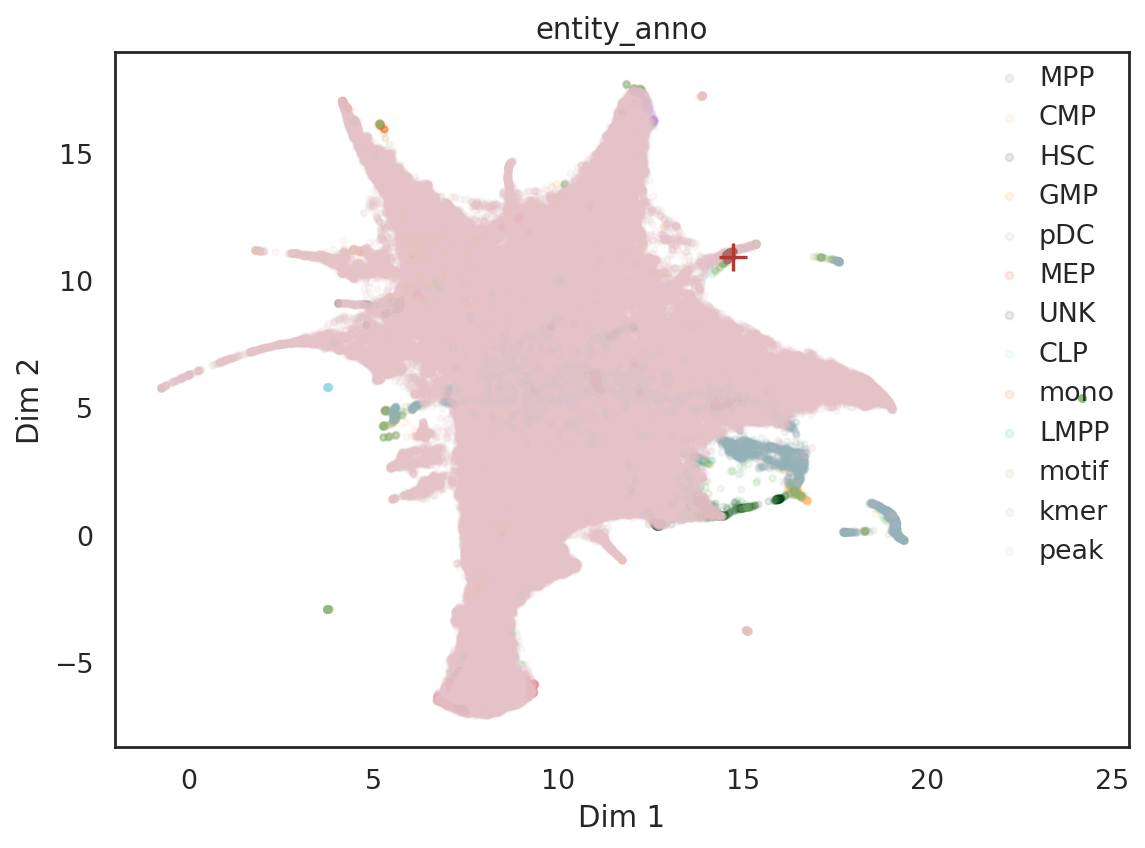

In [54]:
si.pl.query(adata_all,
            obsm='X_umap',
            color=['entity_anno'],
            dict_palette={'entity_anno': palette_entity_anno},
            show_texts=False,
            alpha=0.9,
            alpha_bg=0.1,
            fig_size=(6.5, 5.5))

## Save Results

In [55]:
adata_CP.write(os.path.join(workdir, 'adata_CP.h5ad'))
adata_PM.write(os.path.join(workdir, 'adata_PM.h5ad'))
adata_PK.write(os.path.join(workdir, 'adata_PK.h5ad'))
adata_C.write(os.path.join(workdir, 'adata_C.h5ad'))
adata_P.write(os.path.join(workdir, 'adata_P.h5ad'))
adata_K.write(os.path.join(workdir, 'adata_K.h5ad'))
adata_M.write(os.path.join(workdir, 'adata_M.h5ad'))
adata_all.write(os.path.join(workdir, 'adata_all.h5ad'))
adata_cmp_CM.write(os.path.join(workdir, 'adata_cmp_CM.h5ad'))
adata_cmp_CK.write(os.path.join(workdir, 'adata_cmp_CK.h5ad'))

print('All results saved to:', workdir)

All results saved to: result_simba_data_atacseq


## Load Saved Results (Optional)

如果需要从磁盘恢复之前保存的结果：

In [ ]:
# adata_CP = si.read_h5ad(os.path.join(workdir, 'adata_CP.h5ad'))
# adata_PM = si.read_h5ad(os.path.join(workdir, 'adata_PM.h5ad'))
# adata_PK = si.read_h5ad(os.path.join(workdir, 'adata_PK.h5ad'))
# adata_C = si.read_h5ad(os.path.join(workdir, 'adata_C.h5ad'))
# adata_P = si.read_h5ad(os.path.join(workdir, 'adata_P.h5ad'))
# adata_K = si.read_h5ad(os.path.join(workdir, 'adata_K.h5ad'))
# adata_M = si.read_h5ad(os.path.join(workdir, 'adata_M.h5ad'))
# adata_all = si.read_h5ad(os.path.join(workdir, 'adata_all.h5ad'))
# adata_cmp_CM = si.read_h5ad(os.path.join(workdir, 'adata_cmp_CM.h5ad'))
# adata_cmp_CK = si.read_h5ad(os.path.join(workdir, 'adata_cmp_CK.h5ad'))